In [1]:
!pip install roboflow
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.

In [2]:
from roboflow import Roboflow
import os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import Counter
from PIL import Image
import random
from PIL import Image, ImageDraw
from IPython.display import Image

# Data Loading

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="RbA8rOJvkm0XmjH94940")
project = rf.workspace("pradeeptha").project("drusen-rnixv")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to drusen-3 in yolov11:: 100%|██████████| 2312/2312 [00:00<00:00, 7243.54it/s]


# Data Analysis

In [4]:
root_dir = "drusen-3"
print("Top-level files and folders:")
print(os.listdir(root_dir))

Top-level files and folders:
['data.yaml', 'README.dataset.txt', 'train', 'valid', 'README.roboflow.txt', 'test']


In [5]:
def summarize_dataset(root_dir="drusen-3"):
    summary = {}
    for split in ["train", "valid", "test"]:
        img_dir = os.path.join(root_dir, split, "images")
        lbl_dir = os.path.join(root_dir, split, "labels")
        
        img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
        lbl_files = sorted([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
        
        img_names = set(os.path.splitext(f)[0] for f in img_files)
        lbl_names = set(os.path.splitext(f)[0] for f in lbl_files)

        
        unmatched_labels = lbl_names - img_names
        unmatched_images = img_names - lbl_names

        summary[split] = {
            "num_images": len(img_files),
            "num_labels": len(lbl_files),
            "images_missing_labels": list(unmatched_images),
            "labels_missing_images": list(unmatched_labels),
        }
    return summary

summary = summarize_dataset()
for split, stats in summary.items():
    print(f"\n{split.upper()}:")
    print(f"  Images: {stats['num_images']}")
    print(f"  Labels: {stats['num_labels']}")
    print(f"  Images missing labels: {len(stats['images_missing_labels'])}")
    print(f"  Labels missing images: {len(stats['labels_missing_images'])}")


TRAIN:
  Images: 1062
  Labels: 1062
  Images missing labels: 0
  Labels missing images: 0

VALID:
  Images: 44
  Labels: 44
  Images missing labels: 0
  Labels missing images: 0

TEST:
  Images: 44
  Labels: 44
  Images missing labels: 0
  Labels missing images: 0


Object count per class:
  Class 0: 3760 objects

Annotations per image:
  Total images with labels: 1150
  Min: 0, Max: 13, Mean: 3.27, Median: 3.0


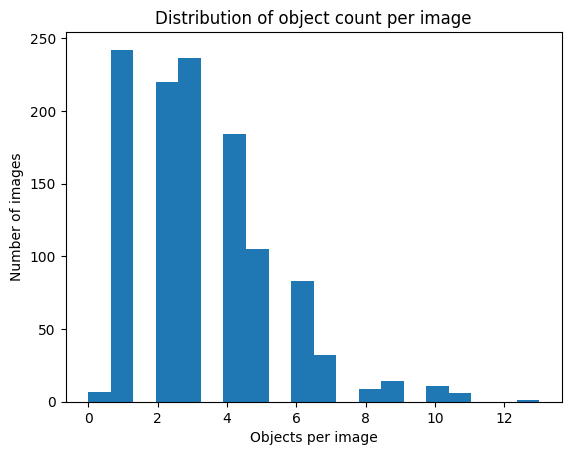

In [6]:
def analyze_annotations(root_dir="drusen-3"):
    class_counts = defaultdict(int)
    annotations_per_image = []

    for split in ["train", "valid", "test"]:
        labels_dir = os.path.join(root_dir, split, "labels")
        label_files = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

        for file in label_files:
            path = os.path.join(labels_dir, file)
            with open(path, "r") as f:
                lines = f.readlines()
                annotations_per_image.append(len(lines))
                for line in lines:
                    class_id = int(line.strip().split()[0])
                    class_counts[class_id] += 1

    return class_counts, annotations_per_image

class_counts, annotations_per_image = analyze_annotations()

print("Object count per class:")
for cls, count in sorted(class_counts.items()):
    print(f"  Class {cls}: {count} objects")

counts = np.array(annotations_per_image)
print("\nAnnotations per image:")
print(f"  Total images with labels: {len(counts)}")
print(f"  Min: {counts.min()}, Max: {counts.max()}, Mean: {counts.mean():.2f}, Median: {np.median(counts)}")

plt.hist(counts, bins=20)
plt.title("Distribution of object count per image")
plt.xlabel("Objects per image")
plt.ylabel("Number of images")
plt.show()

Object count per class:
  Class 0: 3760 objects

Annotations per image:
  Total images with labels: 1150
  Min: 0, Max: 13, Mean: 3.27, Median: 3.0


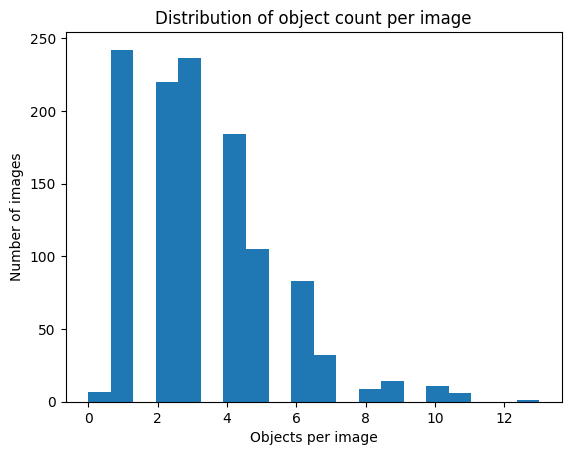

In [7]:
def analyze_annotations(root_dir="drusen-3"):
    class_counts = defaultdict(int)
    annotations_per_image = []

    for split in ["train", "valid", "test"]:
        labels_dir = os.path.join(root_dir, split, "labels")
        label_files = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

        for file in label_files:
            path = os.path.join(labels_dir, file)
            with open(path, "r") as f:
                lines = f.readlines()
                annotations_per_image.append(len(lines))
                for line in lines:
                    class_id = int(line.strip().split()[0])
                    class_counts[class_id] += 1

    return class_counts, annotations_per_image

class_counts, annotations_per_image = analyze_annotations()

print("Object count per class:")
for cls, count in sorted(class_counts.items()):
    print(f"  Class {cls}: {count} objects")

counts = np.array(annotations_per_image)
print("\nAnnotations per image:")
print(f"  Total images with labels: {len(counts)}")
print(f"  Min: {counts.min()}, Max: {counts.max()}, Mean: {counts.mean():.2f}, Median: {np.median(counts)}")

plt.hist(counts, bins=20)
plt.title("Distribution of object count per image")
plt.xlabel("Objects per image")
plt.ylabel("Number of images")
plt.show()

Polygon vertex count stats:
  Min: 5, Max: 27, Mean: 8.77, Median: 8.0

Polygon area stats (in pixels):
  Min: 29.84, Max: 16528.99, Mean: 1401.70, Median: 1096.22


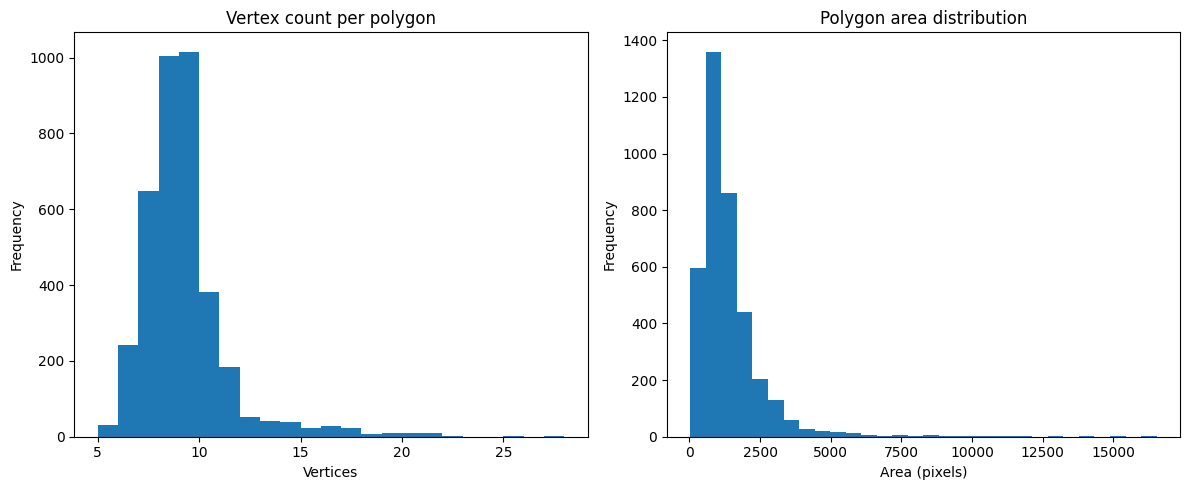

In [8]:
from PIL import Image

def polygon_area(xy):
    
    x = [p[0] for p in xy]
    y = [p[1] for p in xy]
    return 0.5 * abs(sum(x[i]*y[i+1] - x[i+1]*y[i] for i in range(-1, len(x)-1)))

def analyze_polygon_shapes(root_dir="drusen-3"):
    vertex_counts = []
    areas = []

    for split in ["train", "valid", "test"]:
        img_dir = os.path.join(root_dir, split, "images")
        lbl_dir = os.path.join(root_dir, split, "labels")

        img_files = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir) if f.endswith((".jpg", ".png"))}
        lbl_files = [f for f in os.listdir(lbl_dir) if f.endswith(".txt")]

        for lbl_file in lbl_files:
            img_id = os.path.splitext(lbl_file)[0]
            if img_id not in img_files:
                continue

            image_path = os.path.join(img_dir, img_files[img_id])
            w, h = Image.open(image_path).size

            with open(os.path.join(lbl_dir, lbl_file), "r") as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    coords = list(map(float, parts[1:]))

                    
                    xy = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]

                    vertex_counts.append(len(xy))
                    areas.append(polygon_area(xy))

    return vertex_counts, areas

vertex_counts, areas = analyze_polygon_shapes()


v = np.array(vertex_counts)
a = np.array(areas)

print("Polygon vertex count stats:")
print(f"  Min: {v.min()}, Max: {v.max()}, Mean: {v.mean():.2f}, Median: {np.median(v)}")

print("\nPolygon area stats (in pixels):")
print(f"  Min: {a.min():.2f}, Max: {a.max():.2f}, Mean: {a.mean():.2f}, Median: {np.median(a):.2f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(v, bins=range(min(v), max(v)+2))
plt.title("Vertex count per polygon")
plt.xlabel("Vertices")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(a, bins=30)
plt.title("Polygon area distribution")
plt.xlabel("Area (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:
def polygon_area(corners):
    
    n = len(corners)
    area = 0.0
    for i in range(n):
        j = (i + 1) % n
        area += corners[i][0] * corners[j][1]
        area -= corners[j][0] * corners[i][1]
    return abs(area) / 2.0

def drusen_coverage_stats(root_dir="drusen-3", split="train"):
    labels_dir = os.path.join(root_dir, split, "labels")
    images_dir = os.path.join(root_dir, split, "images")

    coverage_percentages = []

    for label_file in os.listdir(labels_dir):
        if not label_file.endswith(".txt"):
            continue

        image_file = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_dir, image_file)
        if not os.path.exists(image_path):
            image_file = label_file.replace(".txt", ".png")
            image_path = os.path.join(images_dir, image_file)
        if not os.path.exists(image_path):
            continue

        image = Image.open(image_path)
        w, h = image.size
        image_area = w * h

        total_drusen_area = 0.0

        with open(os.path.join(labels_dir, label_file), "r") as f:
            for line in f:
                parts = line.strip().split()
                coords = list(map(float, parts[1:]))
                polygon = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
                total_drusen_area += polygon_area(polygon)

        coverage_percentage = (total_drusen_area / image_area) * 100
        coverage_percentages.append(coverage_percentage)

    coverage_percentages = np.array(coverage_percentages)
    print(f"Drusen area coverage (%) stats for {split} set:")
    print(f"  Min: {coverage_percentages.min():.4f}")
    print(f"  Max: {coverage_percentages.max():.4f}")
    print(f"  Mean: {coverage_percentages.mean():.4f}")
    print(f"  Median: {np.median(coverage_percentages):.4f}")

    return coverage_percentages

coverage = drusen_coverage_stats()

Drusen area coverage (%) stats for train set:
  Min: 0.0000
  Max: 5.1286
  Mean: 1.1323
  Median: 0.9541


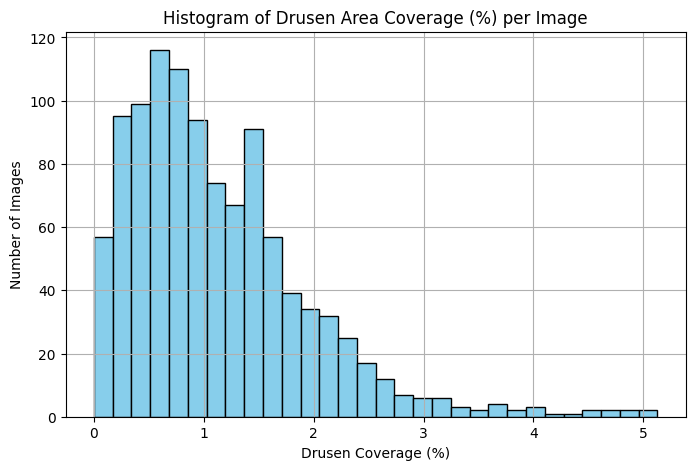

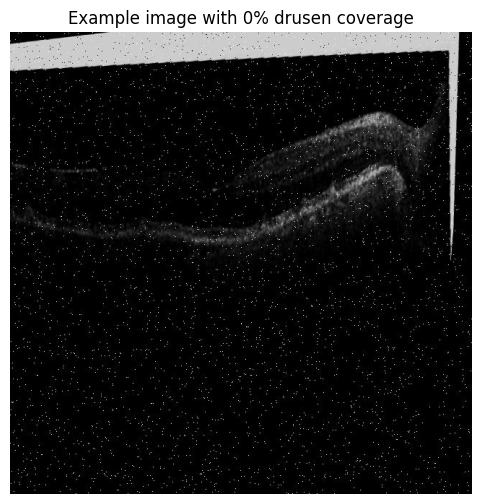

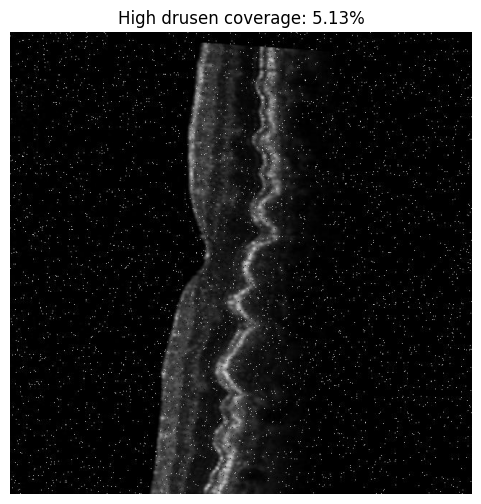

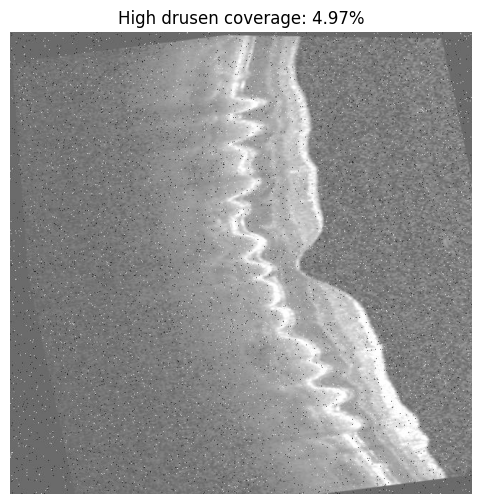

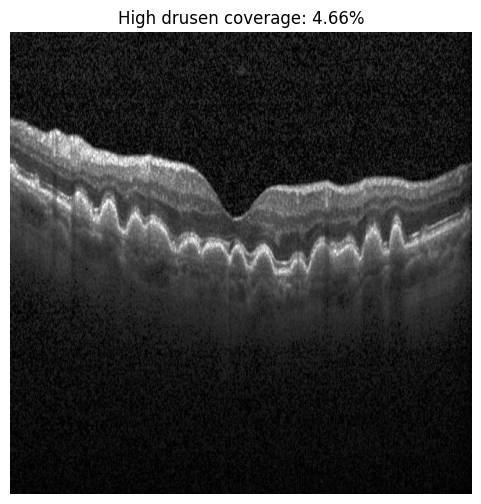

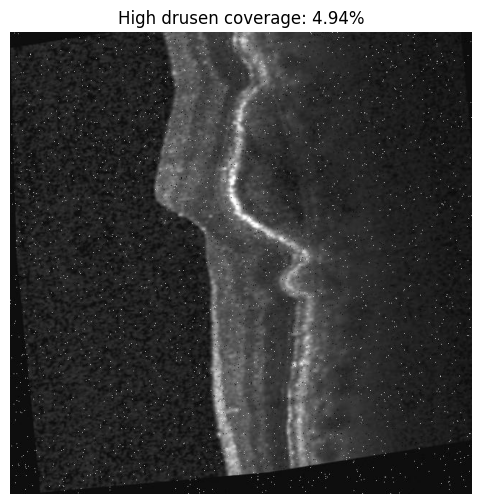

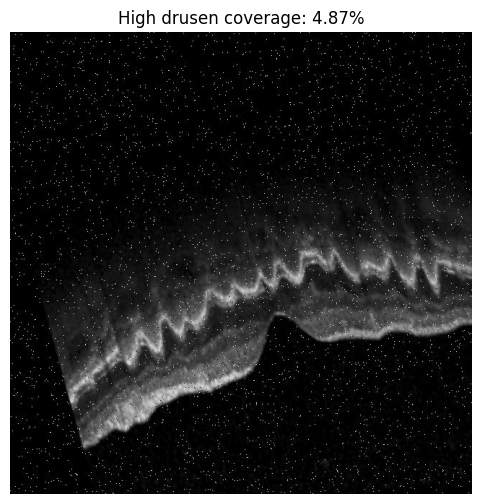

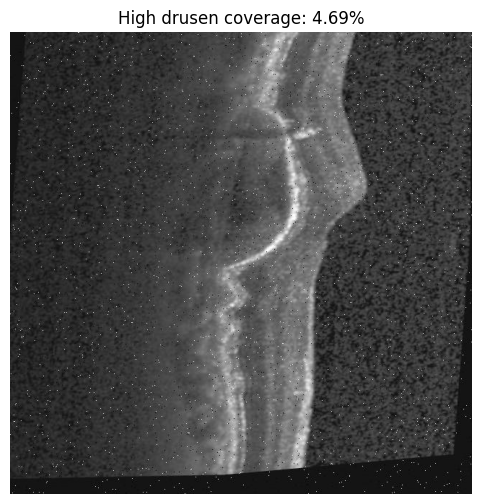

In [10]:
def plot_coverage_histogram(coverage, bins=30):
    plt.figure(figsize=(8, 5))
    plt.hist(coverage, bins=bins, color="skyblue", edgecolor="black")
    plt.title("Histogram of Drusen Area Coverage (%) per Image")
    plt.xlabel("Drusen Coverage (%)")
    plt.ylabel("Number of Images")
    plt.grid(True)
    plt.show()

def find_and_show_extreme_images(root_dir="drusen-3", split="train", coverage_threshold=0.9):
    labels_dir = os.path.join(root_dir, split, "labels")
    images_dir = os.path.join(root_dir, split, "images")

    zero_coverage_images = []
    high_coverage_images = []

    for label_file in os.listdir(labels_dir):
        if not label_file.endswith(".txt"):
            continue

        image_file = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_dir, image_file)
        if not os.path.exists(image_path):
            image_file = label_file.replace(".txt", ".png")
            image_path = os.path.join(images_dir, image_file)
        if not os.path.exists(image_path):
            continue

        image = Image.open(image_path)
        w, h = image.size
        image_area = w * h

        total_drusen_area = 0.0

        with open(os.path.join(labels_dir, label_file), "r") as f:
            for line in f:
                parts = line.strip().split()
                coords = list(map(float, parts[1:]))
                polygon = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
                total_drusen_area += polygon_area(polygon)

        coverage_percentage = (total_drusen_area / image_area) * 100

        if coverage_percentage == 0:
            zero_coverage_images.append(image_path)
        elif coverage_percentage >= coverage_threshold * 5.1286:  
            high_coverage_images.append((image_path, coverage_percentage))

    
    if zero_coverage_images:
        img_path = zero_coverage_images[0]
        img = Image.open(img_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title("Example image with 0% drusen coverage")
        plt.axis("off")
        plt.show()

    
    for img_path, cov in high_coverage_images:
        img = Image.open(img_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"High drusen coverage: {cov:.2f}%")
        plt.axis("off")
        plt.show()


plot_coverage_histogram(coverage)

find_and_show_extreme_images()

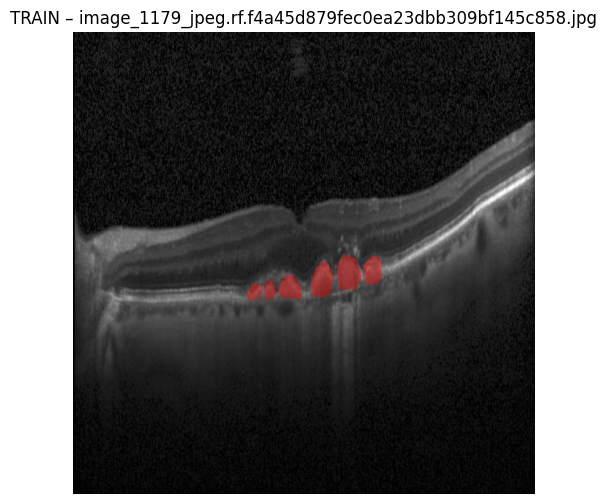

In [11]:
root_dir = "drusen-3"
split = "train"  
images_dir = os.path.join(root_dir, split, "images")
labels_dir = os.path.join(root_dir, split, "labels")


image_files = [f for f in os.listdir(images_dir) if f.endswith((".jpg", ".png"))]
image_file = random.choice(image_files)
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt").replace(".png", ".txt"))


image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image, "RGBA")


w, h = image.size


if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            if len(parts) > 5:
                
                coords = list(map(float, parts[1:]))
                polygon = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
                draw.polygon(polygon, fill=(255, 0, 0, 100))  
else:
    print("No label file for", image_file)


plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"{split.upper()} – {image_file}")
plt.axis("off")
plt.show()

# Model Training

In [12]:
from ultralytics import YOLO
model = YOLO("yolo11m-seg.pt")
model.train(
    task="segment",               
    data=f"{dataset.location}/data.yaml",  
    epochs=20,                    
    imgsz=640                     
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/drusen-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b613a55e3c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 